# Problem Definition
### Many venture capital firms and entrepreneurs struggle to identify which operational areas most significantly impact a startup's bottom line. In a competitive market, spending resources inefficiently can lead to business failure.
### Predict salary of the employees using Simple regression model

## EDA


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split



In [60]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


file_path = "50_Startups.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "farhanmd29/50-startups",
  file_path,
)

print(df.head())

/tmp/ipykernel_9095/1854553237.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the '50-startups' dataset.
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


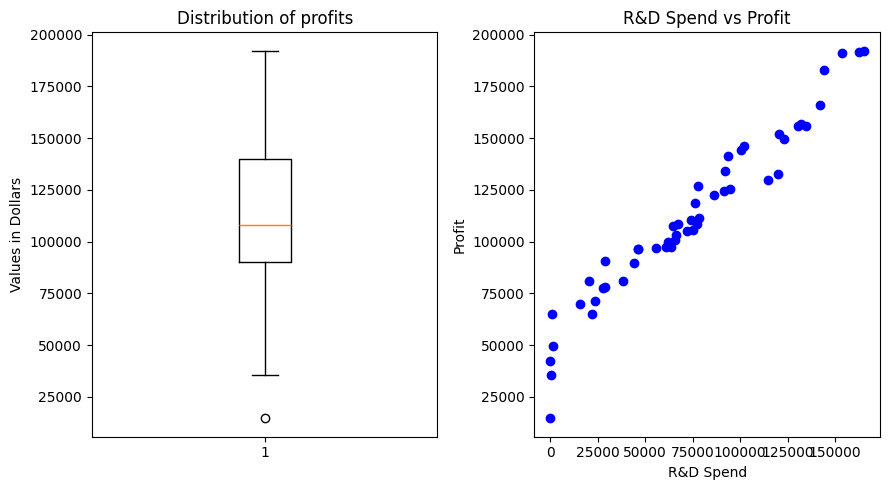

In [62]:
## Analyze Profits
plt.figure(figsize=(9,5))
plt.subplot(1, 2, 1)
plt.boxplot(df['Profit'])
plt.title('Distribution of profits')
plt.ylabel('Values in Dollars')
plt.subplot(1,2,2)
plt.scatter(df['R&D Spend'], df['Profit'], color='blue')
plt.title('R&D Spend vs Profit')
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.tight_layout() # <--- Step 2: The "Magic" fix for overlapping
plt.show()

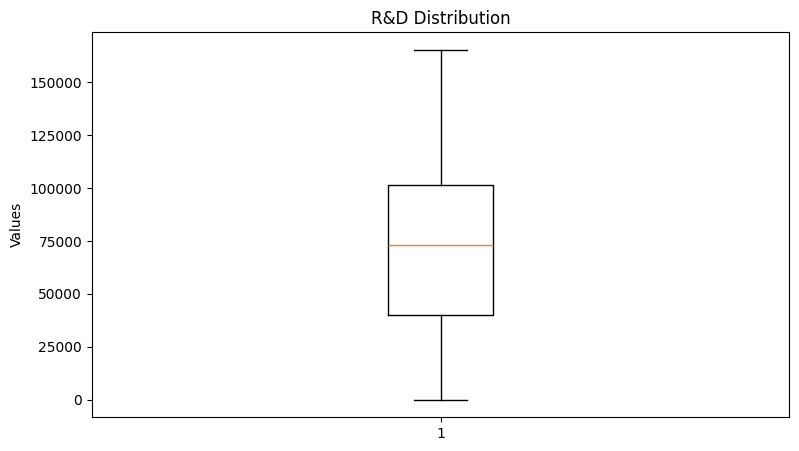

In [63]:
plt.figure(figsize=(9,5))
plt.boxplot(df['R&D Spend'])
plt.title('R&D Distribution')
plt.ylabel('Values')
plt.show()

# Model Training




### The Math Behind the Model

A simple linear regression follows the formula for a straight line:

y = mx + c

Where:

* y = Profit (Dependent variable)
* x = R&D Spend (Independent variable)
* m = Slope (How much profit increases per dollar of R&D)
* c = Intercept (The profit if R&D spend was zero)



In [64]:
def train_simple_regression(X, y):
    mean_x = np.mean(X)
    mean_y = np.mean(y)
    numerator = np.sum((X - mean_x) * (y - mean_y))
    denominator = np.sum((X - mean_x)**2)
    m = numerator / denominator
    c = mean_y - (m * mean_x)
    def predict(new_x):
        return (m * new_x) + c
    return m, c, predict



In [65]:
# 1. Preparing Data (Using only R&D Spend and Profit)
X = df['R&D Spend'].values
y = df['Profit'].values

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,shuffle=True)

In [67]:
_, _, predict = train_simple_regression(X, y)


In [68]:
int(predict(50000))
y_pred = predict(X_test)

In [69]:
## Evaluation metrics
def regression_metrics(y_test, y_pred):
    n = len(y_test)
    mae = int(np.mean(np.abs(y_test - y_pred)))
    mse = int(np.mean((y_test - y_pred) ** 2))
    rmse = int(np.sqrt(mse))
    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2 = float(1 - (ss_res / ss_tot))
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2 }

In [70]:
regression_metrics(y_test, y_pred)

{'MAE': 5973, 'MSE': 58929220, 'RMSE': 7676, 'R2': 0.9272291955974322}

In [71]:
y_train_pred = predict(X_train)
regression_metrics( y_train, y_train_pred)

{'MAE': 7145, 'MSE': 91668859, 'RMSE': 9574, 'R2': 0.9467492888521136}

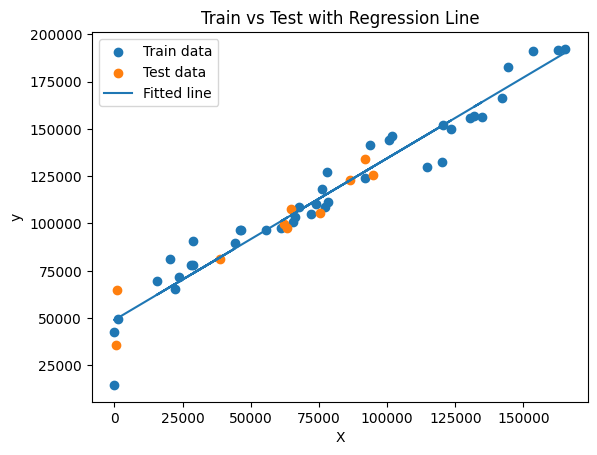

In [72]:
# Plot
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")

y_all_pred = predict(X)

plt.plot(X, y_all_pred, label="Fitted line")

plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("Train vs Test with Regression Line")
plt.show()